<p style="text-align:center">

</p>


# **Project: Exploratory Data Analysis - Laptops Pricing dataset**



In this project, we will explore the effect of different features on the price of laptops. 


# Objectives



 - Visualize individual feature patterns
 - Run descriptive statistical analysis on the dataset
 - Use groups and pivot tables to find the effect of categorical variables on price
 - Use Pearson Correlation to measure the interdependence between variables


# Setup


For this project, we will be using the following libraries:

* `skillsnetwork` for downloading the data
*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`scipy`](https://docs.scipy.org/doc/scipy/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for statistical operations.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


# Install Required Libraries

We can install the required libraries by simply running the `pip install` command with a `%` sign before it. For this environment, `seaborn` library requires installation.


In [1]:
import piplite
await piplite.install('seaborn')

### Importing Required Libraries

_Import all required libraries in one place (here):_


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import pearsonr
%matplotlib inline

# Import the dataset

Download the CSV file to this environment.


The functions below will download the dataset into the browser:


In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

In [4]:
filepath="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [5]:
await download(filepath, "laptops.csv")
file_name="laptops.csv"

Import the file to a pandas dataframe.


In [6]:
df = pd.read_csv(file_name, header=0)

> Note: This version of the lab is working on JupyterLite, which requires the dataset to be downloaded to the interface. While working on the downloaded version of this notebook on their local machines, the learners can simply **skip the steps above**, and simply use the URL directly in the `pandas.read_csv()` function. You can uncomment and run the statements in the cell below.


In [ ]:
#filepath="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
#df = pd.read_csv(filepath, header=None)

Print the first 5 entries of the dataset to confirm loading.


In [7]:
df.head(5)

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


# Task 1 - Visualize individual feature patterns

### Continuous valued features
Let's generate regression plots for each of the parameters "CPU_frequency", "Screen_Size_inch" and "Weight_pounds" against "Price". Also, we print the value of correlation of each feature with "Price".


<AxesSubplot:xlabel='CPU_frequency', ylabel='Price'>

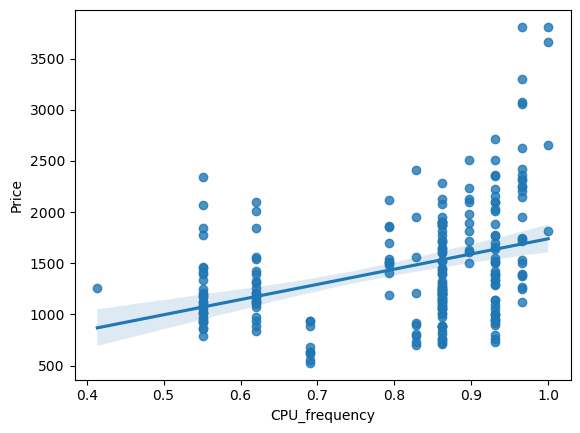

In [9]:
# CPU_frequency plot
sns.regplot(x="CPU_frequency",y="Price",data=df)

<AxesSubplot:xlabel='Screen_Size_inch', ylabel='Price'>

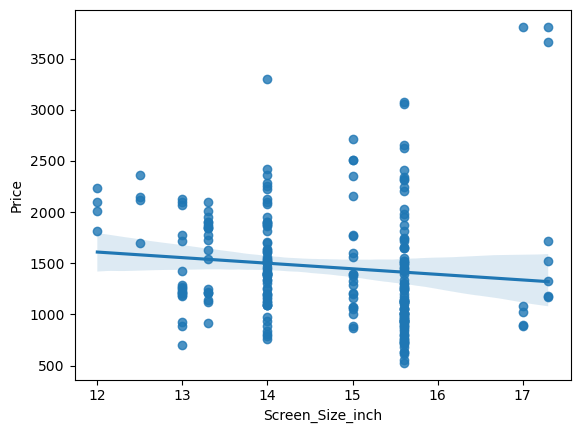

In [10]:
# Screen_Size_inch plot
sns.regplot(x="Screen_Size_inch",y="Price",data=df)

<AxesSubplot:xlabel='Weight_pounds', ylabel='Price'>

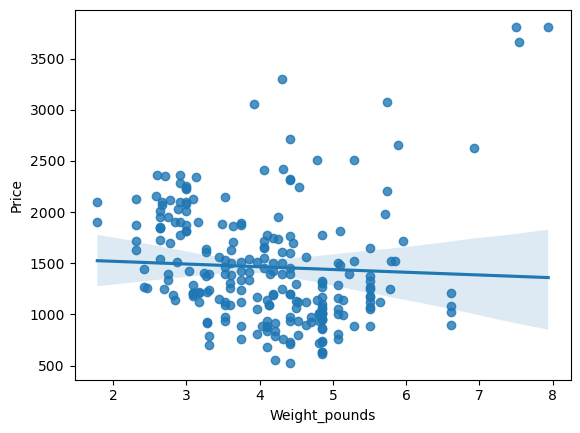

In [11]:
# Weight_pounds plot
sns.regplot(x="Weight_pounds",y="Price",data=df)

In [13]:
# Correlation values of the three attributes with Price
df[["CPU_frequency","Screen_Size_inch","Weight_pounds","Price"]].corr()

#OR
#for param in ["CPU_frequency", "Screen_Size_inch","Weight_pounds"]:
#    print(f"Correlation of Price and {param} is ", df[[param,"Price"]].corr())

,CPU_frequency,Screen_Size_inch,Weight_pounds,Price
CPU_frequency,1.000000,-0.000948,0.066522,0.366666
Screen_Size_inch,-0.000948,1.000000,0.797534,-0.110644
Weight_pounds,0.066522,0.797534,1.000000,-0.050312
Price,0.366666,-0.110644,-0.050312,1.000000


Interpretation: "CPU_frequency" has a 36% positive correlation with the price of the laptops. The other two parameters have weak correlation with price.


### Categorical features
We generate Box plots for the different feature that hold categorical values. These features would be "Category", "GPU", "OS", "CPU_core", "RAM_GB", "Storage_GB_SSD"


<AxesSubplot:xlabel='Category', ylabel='Price'>

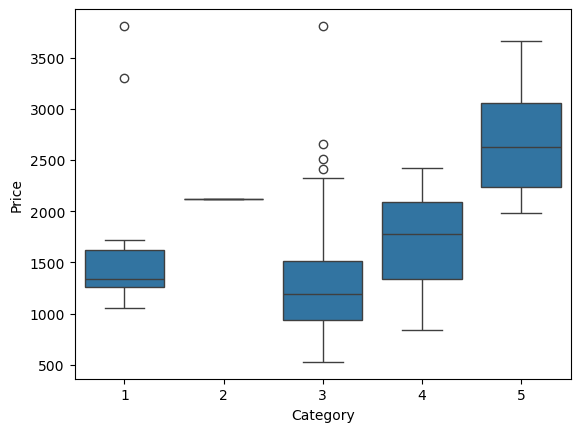

In [15]:
# Category Box plot
sns.boxplot(x="Category",y="Price",data=df)

<AxesSubplot:xlabel='GPU', ylabel='Price'>

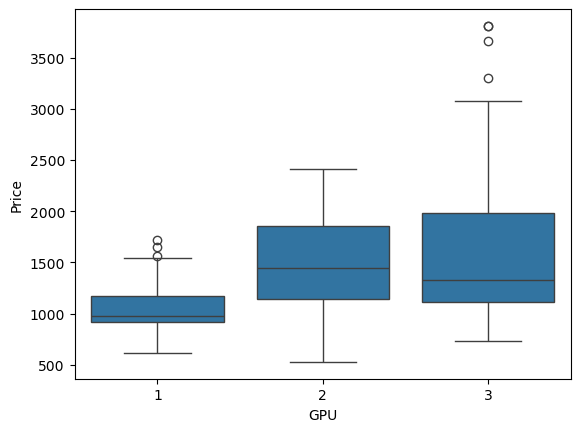

In [16]:
# GPU Box plot
sns.boxplot(x="GPU",y="Price",data=df)

<AxesSubplot:xlabel='OS', ylabel='Price'>

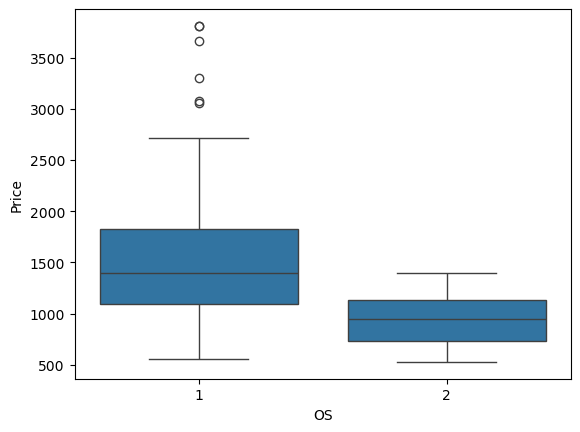

In [17]:
# OS Box plot
sns.boxplot(x="OS",y="Price",data=df)

<AxesSubplot:xlabel='CPU_core', ylabel='Price'>

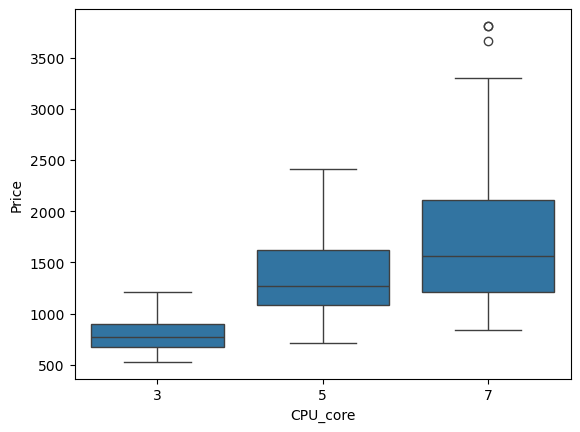

In [18]:
# CPU_core Box plot
sns.boxplot(x="CPU_core",y="Price",data=df)

<AxesSubplot:xlabel='RAM_GB', ylabel='Price'>

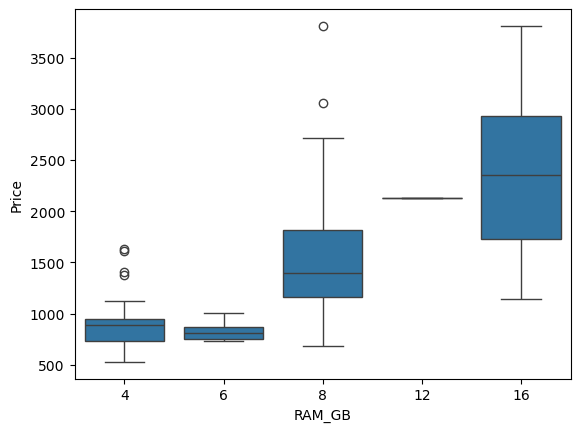

In [19]:
# RAM_GB Box plot
sns.boxplot(x="RAM_GB",y="Price",data=df)

<AxesSubplot:xlabel='Storage_GB_SSD', ylabel='Price'>

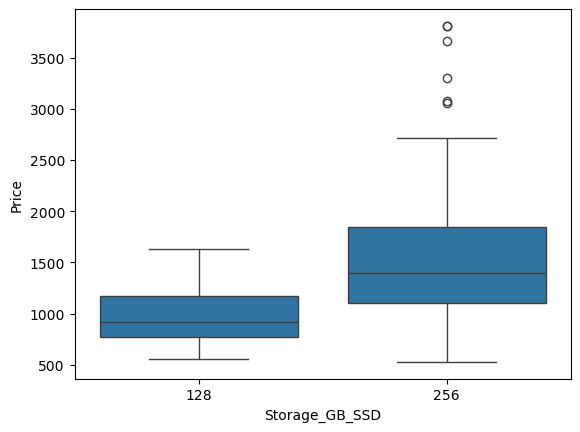

In [20]:
# Storage_GB_SSD Box plot
sns.boxplot(x="Storage_GB_SSD",y="Price",data=df)

# Task 2 - Descriptive Statistical Analysis


Let's generate the statistical description of all the features being used in the data set. Include "object" data types as well.


In [21]:
df.describe(include="all")

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
count,238.000000,238.000000,238,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000,238,238.000000,238.000000
unique,NaN,NaN,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Dell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN
freq,NaN,NaN,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160,NaN,NaN
mean,118.500000,118.500000,NaN,3.205882,2.151261,1.058824,5.630252,14.688655,0.813822,7.882353,245.781513,4.106221,1462.344538,NaN,0.676471,0.323529
std,68.848868,68.848868,NaN,0.776533,0.638282,0.235790,1.241787,1.166045,0.141860,2.482603,34.765316,1.078442,574.607699,NaN,0.468809,0.468809
min,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,3.000000,12.000000,0.413793,4.000000,128.000000,1.786050,527.000000,NaN,0.000000,0.000000
25%,59.250000,59.250000,NaN,3.000000,2.000000,1.000000,5.000000,14.000000,0.689655,8.000000,256.000000,3.246863,1066.500000,NaN,0.000000,0.000000
50%,118.500000,118.500000,NaN,3.000000,2.000000,1.000000,5.000000,15.000000,0.862069,8.000000,256.000000,4.106221,1333.000000,NaN,1.000000,0.000000
75%,177.750000,177.750000,NaN,4.000000,3.000000,1.000000,7.000000,15.600000,0.931034,8.000000,256.000000,4.851000,1777.000000,NaN,1.000000,1.000000


# Task 3 - GroupBy and Pivot Tables

We now group the parameters "GPU", "CPU_core" and "Price" to make a pivot table and visualize this connection using the pcolor plot.


In [23]:
# Create the group
group1 = df[["GPU","CPU_core","Price"]]
grouped1 = group1.groupby(["GPU","CPU_core"],as_index=False).mean()
grouped1

,GPU,CPU_core,Price
0,1,3,769.250000
1,1,5,998.500000
2,1,7,1167.941176
3,2,3,785.076923
4,2,5,1462.197674
5,2,7,1744.621622
6,3,3,784.000000
7,3,5,1220.680000
8,3,7,1945.097561


In [25]:
# Create the Pivot table
pivot1 = grouped1.pivot(index="GPU",columns="CPU_core")
pivot1

Price                          
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561

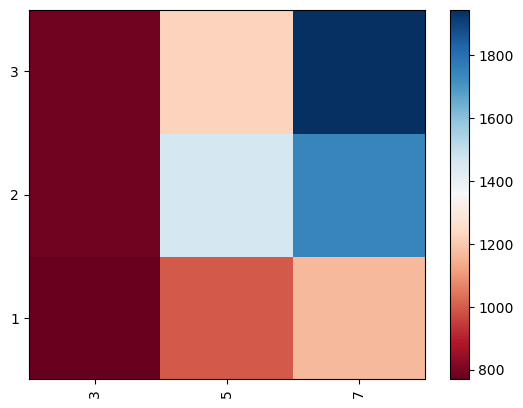

In [29]:
# Create the Plot
#plt.pcolor(pivot1)
#plt.colorbar()
#plt.show

fig, ax = plt.subplots()
im = ax.pcolor(pivot1, cmap='RdBu')

#label names
row_labels = pivot1.columns.levels[1]
col_labels = pivot1.index

#move ticks and labels to the center
ax.set_xticks(np.arange(pivot1.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(pivot1.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

# Task 4 - Pearson Correlation and p-values

Here, we use the `scipy.stats.pearsonr()` function to evaluate the Pearson Coefficient and the p-values for each parameter tested above. This will help us determine the parameters most likely to have a strong effect on the price of the laptops.


In [45]:
pearson_coef,p_value = scipy.stats.pearsonr(df["Category"],df["Price"])
print("The pearson coef for Category and Price is:",pearson_coef)
print("The p value is: ",p_value)

The pearson coef for Category and Price is: 0.286242755812641
The p value is:  7.225696235806858e-06


In [37]:
pearson_coef,p_value = scipy.stats.pearsonr(df["GPU"],df["Price"])
print("The pearson coef for GPU and Price is:",pearson_coef)
print("The p value is: ",p_value)

The pearson coef for GPU and Price is: 0.2882981988881427
The p value is:  6.166949698364507e-06


In [38]:
pearson_coef,p_value = scipy.stats.pearsonr(df["OS"],df["Price"])
print("The pearson coef for OS and Price is:",pearson_coef)
print("The p value is: ",p_value)

The pearson coef for OS and Price is: -0.22172980114827356
The p value is:  0.0005696642559246817


In [39]:
pearson_coef,p_value = scipy.stats.pearsonr(df["CPU_core"],df["Price"])
print("The pearson coef for CPU_core and Price is:",pearson_coef)
print("The p value is: ",p_value)

The pearson coef for CPU_core and Price is: 0.45939777733551174
The p value is:  7.912950127008979e-14


In [40]:
pearson_coef,p_value = scipy.stats.pearsonr(df["Screen_Size_inch"],df["Price"])
print("The pearson coef for Screen_Size_inch and Price is:",pearson_coef)
print("The p value is: ",p_value)

The pearson coef for Screen_Size_inch and Price is: -0.11064420817118291
The p value is:  0.08853397846830661


In [41]:
pearson_coef,p_value = scipy.stats.pearsonr(df["CPU_frequency"],df["Price"])
print("The pearson coef for CPU_frequency and Price is:",pearson_coef)
print("The p value is: ",p_value)

The pearson coef for CPU_frequency and Price is: 0.3666655589258861
The p value is:  5.50246335071342e-09


In [42]:
pearson_coef,p_value = scipy.stats.pearsonr(df["RAM_GB"],df["Price"])
print("The pearson coef for RAM_GB and Price is:",pearson_coef)
print("The p value is: ",p_value)

The pearson coef for RAM_GB and Price is: 0.5492972971857849
The p value is:  3.6815606288424503e-20


In [43]:
pearson_coef,p_value = scipy.stats.pearsonr(df["Storage_GB_SSD"],df["Price"])
print("The pearson coef for Storage_GB_SSD and Price is:",pearson_coef)
print("The p value is: ",p_value)

The pearson coef for Storage_GB_SSD and Price is: 0.24342075521810297
The p value is:  0.00014898923191724168


In [44]:
pearson_coef,p_value = scipy.stats.pearsonr(df["Weight_pounds"],df["Price"])
print("The pearson coef for Weight_pounds and Price is:",pearson_coef)
print("The p value is: ",p_value)

The pearson coef for Weight_pounds and Price is: -0.050312258377515455
The p value is:  0.4397693853433894
